<a href="https://colab.research.google.com/github/hanmtay/IntroToAI_A2/blob/main/section2_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/hanmtay/IntroToAI_A2.git
%cd IntroToAI_A2

Cloning into 'IntroToAI_A2'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 120 (delta 70), reused 64 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 675.72 KiB | 9.01 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/IntroToAI_A2


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.lines import Line2D

loading in data

In [4]:
df = pd.read_csv('a2_Hannah_Taylor_40443054/40443054_features.csv')

features chosen

In [5]:
my_features = ['rows_with_1', 'cols_with_2', 'hollowness', 'height']

Task 2.1

k Value    | Accuracy (%)   
------------------------------
1          | 100.00         
3          | 95.54          
5          | 94.64          
7          | 91.07          
9          | 91.96          
11         | 91.07          
13         | 91.07          
15         | 90.18          


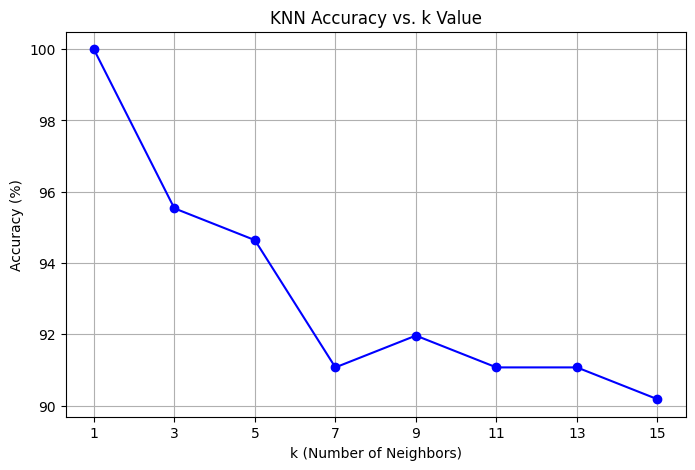

In [10]:
#task2.1
X = df[my_features]
y = df['label']

k_values = [1, 3, 5, 7, 9, 11, 13, 15]

#store results from knn
results = []

print(f"{'k Value':<10} | {'Accuracy (%)':<15}")
print("-" * 30)

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)


    knn.fit(X, y)

    y_pred = knn.predict(X)

    acc = accuracy_score(y, y_pred) * 100
    results.append(acc)

    print(f"{k:<10} | {acc:<15.2f}")


plt.figure(figsize=(8, 5))
plt.plot(k_values, results, marker='o', linestyle='-', color='b')
plt.title('KNN Accuracy vs. k Value')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.grid(True)
plt.savefig('KNN21.png')
plt.show()

Task 2.2

k Value    | CV Accuracy (%)
-----------------------------------
1          | 90.18          
3          | 91.07          
5          | 88.39          
7          | 90.18          
9          | 87.50          
11         | 87.50          
13         | 85.71          
15         | 83.04          


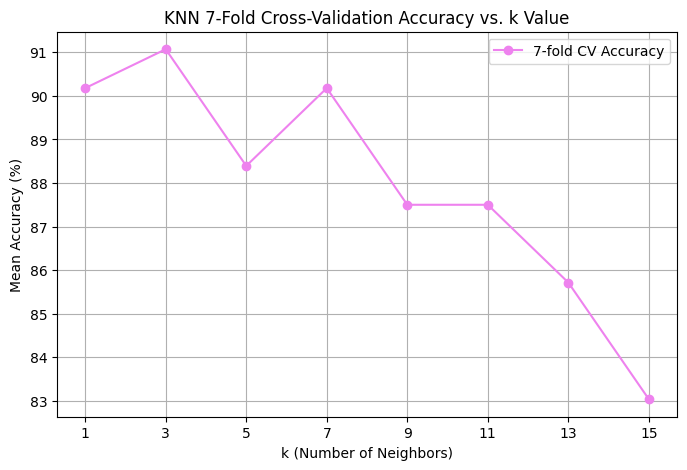

In [11]:
#task 2.2

#same X and y from above

#7 fold cv
kf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

#store cv results
cv_results = []

print(f"{'k Value':<10} | {'CV Accuracy (%)':<15}")
print("-" * 35)

for k in k_values:

    knn_cv = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn_cv, X, y, cv=kf)

    mean_acc = scores.mean() * 100
    cv_results.append(mean_acc)

    print(f"{k:<10} | {mean_acc:<15.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_results, marker='o', linestyle='-', color='violet', label='7-fold CV Accuracy')
plt.title('KNN 7-Fold Cross-Validation Accuracy vs. k Value')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Mean Accuracy (%)')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.savefig('KNN22_CV.png')
plt.show()

task 2.3

<Figure size 1000x800 with 0 Axes>

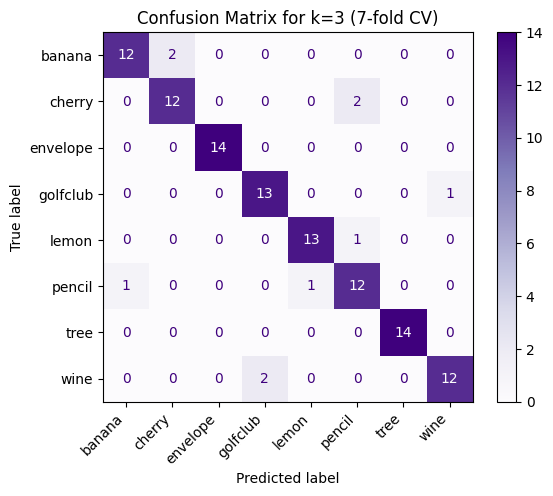

In [12]:
#task 2.3

#best k value from above is 3
knn_best = KNeighborsClassifier(n_neighbors=3)
y_pred_cv = cross_val_predict(knn_best, X, y, cv=kf)

cm = confusion_matrix(y, y_pred_cv)
#from: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Purples', values_format='d')
# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.title(f'Confusion Matrix for k={3} (7-fold CV)')
plt.savefig('cm23.png')
plt.show()

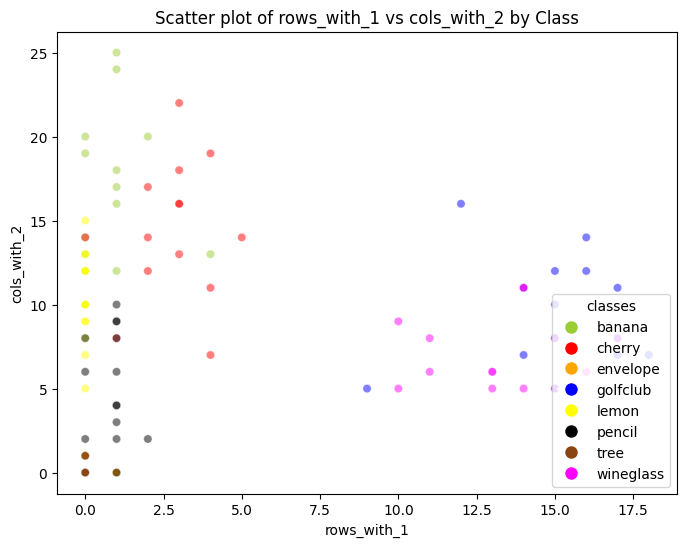

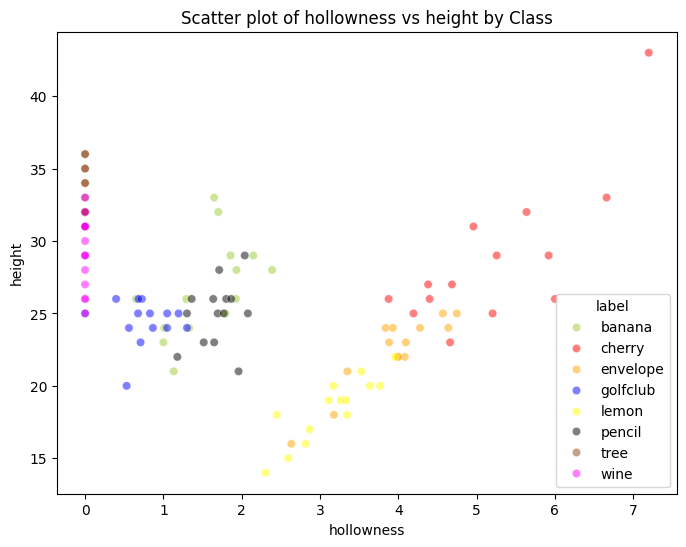

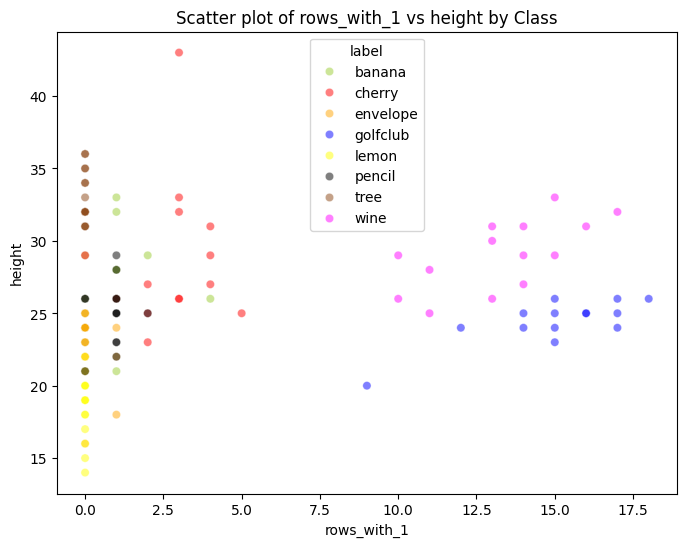

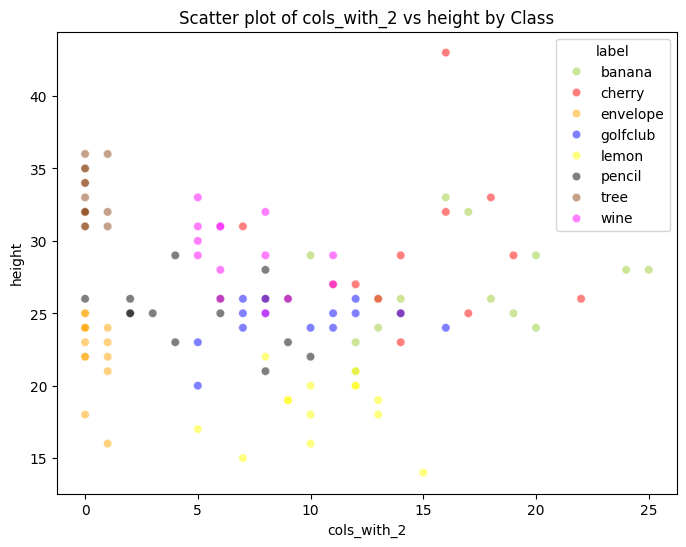

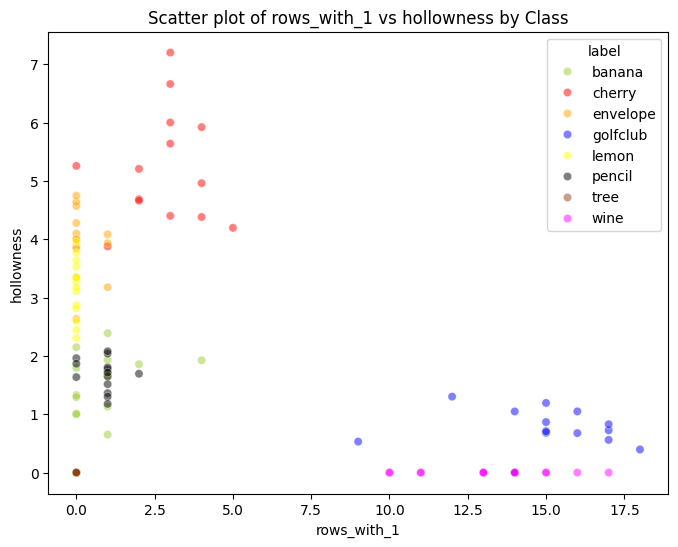

In [9]:
# Define the feature columns
features1 = ['rows_with_1', 'cols_with_2']

# Custom color palette for species
palette = {'banana': 'yellowgreen', 'cherry': 'red', 'envelope': 'orange', 'golfclub': 'blue', 'lemon': 'yellow', 'pencil': 'black', 'tree': 'saddlebrown', 'wine': 'magenta'}

# Create the scatter plot with blue and red colors

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='rows_with_1', y='cols_with_2', hue='label', palette=palette, alpha=0.5)

# Set plot title and labels
plt.title("Scatter plot of rows_with_1 vs cols_with_2 by Class")

# Creating custom legend matching the scatter plot colors
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellowgreen', markersize=10, label='banana'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='cherry'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='envelope'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='golfclub'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label='lemon'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='pencil'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='saddlebrown', markersize=10, label='tree'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='magenta', markersize=10, label='wineglass')
]

# Adding the custom legend to the plot
plt.legend(handles=legend_elements, title="classes", loc='lower right', fontsize=10)

#second graph
features2 = ['hollowness', 'height']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='hollowness', y='height', hue='label', palette=palette, alpha=0.5)

plt.title("Scatter plot of hollowness vs height by Class")

#third graph
features3 = ['rows_with_1', 'height']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='rows_with_1', y='height', hue='label', palette=palette, alpha=0.5)

plt.title("Scatter plot of rows_with_1 vs height by Class")

#fourth graph
features4 = ['cols_with_2', 'height']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='cols_with_2', y='height', hue='label', palette=palette, alpha=0.5)

plt.title("Scatter plot of cols_with_2 vs height by Class")

#fifth graph
features4 = ['rows_with_1', 'hollowness']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='rows_with_1', y='hollowness', hue='label', palette=palette, alpha=0.5)

plt.title("Scatter plot of rows_with_1 vs hollowness by Class")

plt.show()

Task 2.4

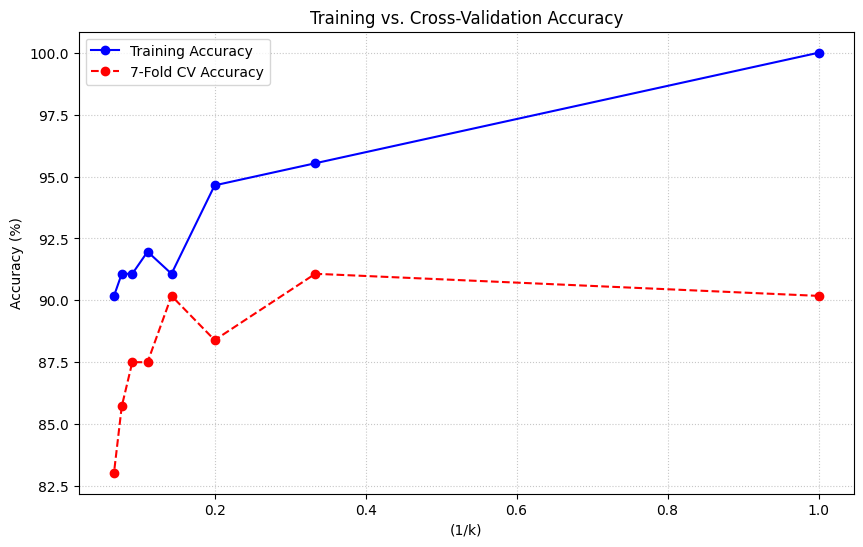

In [16]:
#task 2.4

oneOverk = [1/k for k in k_values]

plt.figure(figsize=(10, 6))

#training accuracy
plt.plot(oneOverk, results, label='Training Accuracy',
         marker='o', linestyle='-', color='blue')

#cross validation accuracy
plt.plot(oneOverk, cv_results, label='7-Fold CV Accuracy',
         marker='o', linestyle='--', color='red')

plt.title('Training vs. Cross-Validation Accuracy')
plt.xlabel('(1/k)')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.savefig('task24 graph.png')
plt.show()